In [65]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### **Ejercicio N°2**
El dataset `registro_temperatura365d_smn.txt` contiene las temperaturas máximas y mínimas registradas diariamente entre el 11/04/2025 y el 10/04/2026 en todas las estaciones meteorológicas de superficie pertenecientes al Servicio Meteorológico Nacional.

1. Explore la estructura del archivo. Notará que no se utiliza un delimitador particular para separar las distintas columnas sino que los distintos campos están alineados en columnas con diferente número de espacios que separan uno del otro. Por este motivo, y aprovechando que las primeras columnas son de ancho fijo, se sugiere utilizar la función `read_fwf()` de Pandas, que permite leer este tipo de archivos. 

```{admonition} **Sobre read_fwf()**
:class: tip

La función **`pd.read_fwf()`** en Pandas se utiliza para leer archivos de texto que tienen columnas de ancho fijo, donde cada columna ocupa una cantidad específica de caracteres. Esta función es útil cuando los datos no están separados por delimitadores como comas o espacios, sino que están organizados en columnas de longitudes fijas.

Al emplear esta función se deben definir los anchos de las columnas mediante el parámetro **`colspecs`**. Esto se hace proporcionando una lista de tuplas, donde cada tupla indica el rango de posiciones que corresponden a cada columna. Como ayuda, en nuestro caso **`colspecs`** comienza con la tupla (0, 8) para definir los límites de la columna **`FECHA`**, es decir: **`colspecs = [(0, 8), ...]`**.

**`read_fwf()`** ignora los espacios en blanco al cargar los datos, por lo que no es necesario preocuparse por los espacios adicionales que puedan existir.
```

In [66]:
smn = pd.read_fwf(
    './datasets/registro_temperatura365d_smn.txt', 
    encoding='latin1', 
    skiprows=[1] # Para saltar la línea de guiones (-------)
)
smn

,FECHA,TMAX,TMIN,NOMBRE
0,--------,-----,-----,----------------------------------------
1,10042026,21.1,13.8,AEROPARQUE AERO
2,10042026,22.6,7.2,AZUL AERO
3,10042026,24.8,11.4,BAHIA BLANCA AERO
4,10042026,24.6,1.2,BARILOCHE AERO
...,...,...,...,...
42975,11042025,19.5,15.5,VIEDMA AERO
42976,11042025,23.4,14.2,VILLA DE MARIA DEL RIO SECO
42977,11042025,25.1,16.2,VILLA DOLORES AERO
42978,11042025,23.1,18.0,VILLA GESELL AERO


In [67]:
smn=smn.drop(index=0)

In [68]:
smn['FECHA'] = pd.to_datetime(smn['FECHA'], format='%d%m%Y')
smn

,FECHA,TMAX,TMIN,NOMBRE
1,2026-04-10,21.1,13.8,AEROPARQUE AERO
2,2026-04-10,22.6,7.2,AZUL AERO
3,2026-04-10,24.8,11.4,BAHIA BLANCA AERO
4,2026-04-10,24.6,1.2,BARILOCHE AERO
5,2026-04-10,-11.4,-18.6,BASE BELGRANO II
...,...,...,...,...
42975,2025-04-11,19.5,15.5,VIEDMA AERO
42976,2025-04-11,23.4,14.2,VILLA DE MARIA DEL RIO SECO
42977,2025-04-11,25.1,16.2,VILLA DOLORES AERO
42978,2025-04-11,23.1,18.0,VILLA GESELL AERO


In [69]:
smn.isnull().sum()

FECHA        0
TMAX      1976
TMIN       702
NOMBRE       0
dtype: int64

In [70]:
smn[(smn['TMAX'].isnull())&(smn['TMIN'].isnull())]

,FECHA,TMAX,TMIN,NOMBRE
611,2026-04-05,NaN,NaN,CHILECITO AERO
655,2026-04-05,NaN,NaN,OBERA
703,2026-04-05,NaN,NaN,VICTORICA
729,2026-04-04,NaN,NaN,CHILECITO AERO
1437,2026-03-29,NaN,NaN,CHILECITO AERO
...,...,...,...,...
42646,2025-04-13,NaN,NaN,CHILECITO AERO
42690,2025-04-13,NaN,NaN,OBERA
42697,2025-04-13,NaN,NaN,PERITO MORENO AERO
42738,2025-04-13,NaN,NaN,VICTORICA


In [71]:
smn=smn.dropna(subset=['TMAX','TMIN'],how='all')

In [72]:
smn.isnull().sum()

FECHA        0
TMAX      1736
TMIN       462
NOMBRE       0
dtype: int64

In [73]:
smn[(smn['TMAX'].isnull())|(smn['TMIN'].isnull())]

,FECHA,TMAX,TMIN,NOMBRE
15,2026-04-10,NaN,5.5,CAMPO DE MAYO AERO
32,2026-04-10,NaN,8.5,ESCUELA DE AVIACION MILITAR AERO
55,2026-04-10,NaN,7.5,MARIANO MORENO AERO
59,2026-04-10,NaN,6.5,MERLO AERO
66,2026-04-10,NaN,6.9,OLAVARRIA AERO
...,...,...,...,...
42918,2025-04-11,NaN,12.8,MENDOZA OBSERVATORIO
42920,2025-04-11,NaN,19.4,MERLO AERO
42944,2025-04-11,NaN,14.6,RIO CUARTO AERO
42950,2025-04-11,NaN,11.1,SAN ANTONIO OESTE AERO


In [74]:
#Paso a numerico TMAX TMIN
smn['TMAX'] = pd.to_numeric(smn['TMAX'])
smn['TMIN'] = pd.to_numeric(smn['TMIN'])

C:\Users\Dark7 120gb\AppData\Local\Temp\ipykernel_15552\1339521410.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  smn['TMAX'] = pd.to_numeric(smn['TMAX'])
C:\Users\Dark7 120gb\AppData\Local\Temp\ipykernel_15552\1339521410.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  smn['TMIN'] = pd.to_numeric(smn['TMIN'])


In [75]:
smn.info()

<class 'pandas.core.frame.DataFrame'>
Index: 42739 entries, 1 to 42979
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   FECHA   42739 non-null  datetime64[ns]
 1   TMAX    41003 non-null  float64       
 2   TMIN    42277 non-null  float64       
 3   NOMBRE  42739 non-null  object        
dtypes: datetime64[ns](1), float64(2), object(1)
memory usage: 1.6+ MB


2. Construya una tabla resumen que contenga media, mediana, desviación estándar y rango intercuartílico de las temperaturas mínimas y máximas registradas por mes. 

In [76]:
smn['AÑO-MES']=smn['FECHA'].dt.to_period('M')

C:\Users\Dark7 120gb\AppData\Local\Temp\ipykernel_15552\123482982.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  smn['AÑO-MES']=smn['FECHA'].dt.to_period('M')


In [85]:
#tengo que crear funcion iqr
def iqr(x):
    return x.quantile(0.75)-x.quantile(0.25)

tabla_resumen=smn.groupby('AÑO-MES')[['TMAX','TMIN']].agg(['mean','median','std', iqr]).round(2)
tabla_resumen

TMAX                     TMIN                    
          mean median   std  iqr   mean median   std    iqr
AÑO-MES                                                    
2025-04  20.72  22.00  7.02  7.9   9.66  10.30  6.27   8.00
2025-05  18.44  19.80  8.11  9.2   7.99   8.70  7.78  10.82
2025-06  14.06  15.50  6.87  7.5   2.46   2.60  6.13   6.60
2025-07  15.07  15.50  7.61  9.1   3.72   4.50  6.60   8.40
2025-08  17.03  18.00  7.95  8.9   4.86   5.20  6.78   7.60
2025-09  20.14  21.05  8.47  9.5   7.42   7.80  7.31   8.40
2025-10  23.04  24.50  8.80  9.1   9.76  10.50  7.06   8.30
2025-11  25.28  26.50  8.68  9.3  12.22  13.20  6.66   7.40
2025-12  28.22  30.30  8.17  7.4  15.24  16.60  6.34   7.30
2026-01  28.81  30.60  7.68  7.2  15.69  17.20  6.26   7.50
2026-02  27.91  29.60  8.01  6.5  15.28  17.00  6.75   8.00
2026-03  25.52  26.80  7.87  6.9  14.03  15.80  7.09   9.10
2026-04  22.20  22.55  8.09  8.3  11.69  12.15  7.54  10.30

In [77]:
smn['TMAX'].agg(['mean', 'median', 'std']).round(2)

#tengo que crear funcion iqr
def iqr(x):
    return x.quantile(0.75)-x.quantile(0.25)

tabla_resumen_MAX=smn['TMAX'].agg(['mean', 'median', 'std', iqr]).round(2)
tabla_resumen_MIN=smn['TMIN'].agg(['mean', 'median', 'std', iqr]).round(2)

tabla_resumen=pd.DataFrame({'Maximas':tabla_resumen_MAX, 'Minimas':tabla_resumen_MIN})
tabla_resumen.index = ['Promedio', 'Mediana', 'Desviación estándar', 'Rango intercuartil']
tabla_resumen

,Maximas,Minimas
Promedio,22.02,9.90
Mediana,23.10,10.50
Desviación estándar,9.41,8.16
Rango intercuartil,12.20,11.70


In [78]:
smn['TMAX'].agg(['mean', 'median', 'std']).round(2)

#tengo que crear funcion iqr
def iqr(x):
    return x.quantile(0.75)-x.quantile(0.25)

tabla_resumen_MAX=smn['TMAX'].agg(['mean', 'median', 'std', iqr]).round(2)
tabla_resumen_MIN=smn['TMIN'].agg(['mean', 'median', 'std', iqr]).round(2)

tabla_resumen=pd.DataFrame({'Maximas':tabla_resumen_MAX, 'Minimas':tabla_resumen_MIN}).T
tabla_resumen.columns = ['Promedio', 'Mediana', 'Desviación estándar', 'Rango intercuartil']
tabla_resumen

,Promedio,Mediana,Desviación estándar,Rango intercuartil
Maximas,22.02,23.1,9.41,12.2
Minimas,9.90,10.5,8.16,11.7


3. Construya un gráfico que le permita comparar las distribuciones de temperaturas mínimas y máximas diarias entre los últimos 10 meses con datos completos (mayo 2025 a marzo 2026) registradas en la estación del Aeropuerto Rosario (”ROSARIO AERO”).

In [104]:
rosario=smn[(smn['NOMBRE']=='ROSARIO AERO')&(smn['FECHA']>='2025-05-01')&(smn['FECHA']<'2026-04-01')]
rosario=rosario.sort_values('FECHA',ascending=True)

C:\Users\Dark7 120gb\AppData\Local\Temp\ipykernel_15552\3648251781.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


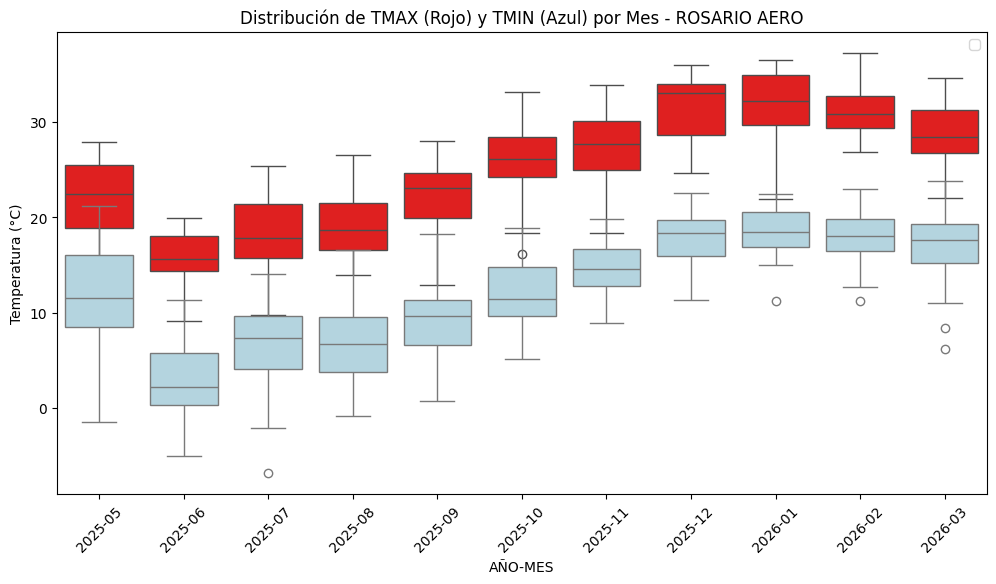

In [ ]:
plt.figure(figsize=(12, 6)) #va antes del grafico
sns.boxplot(x='AÑO-MES', y='TMAX', data=rosario, color='red')
sns.boxplot(x='AÑO-MES', y='TMIN', data=rosario, color='lightblue')
plt.title('Distribución de TMAX (Rojo) y TMIN (Celeste) por Mes - ROSARIO AERO')
plt.xticks(rotation=45)
plt.ylabel('Temperatura (°C)')
plt.show()

4. En base a lo realizado en los dos ítems anteriores, responda las siguientes preguntas:

    a. ¿Cuál fue el mes del último año con la mayor temperatura máxima mediana?

        * Fue Diciembre 2025

    b. ¿Cuál fue el mes del último año con la menor temperatura mínima mediana?

        * Fue Junio 2025
  
    c. Considerando la variabilidad del 50 % central de las temperaturas registradas en el mes, ¿cuál fue el mes del último año con una menor dispersión tanto en sus temperaturas mínimas como en sus temperaturas máximas? 

        * Febrero 2026?
  
    d. ¿Cuál fue el mes del último año que presentó una mayor amplitud en sus temperaturas mínimas registradas?

        * Mayo 2025

    e. Considerando los meses del invierno 2025, ¿existió algún mes en el cual se haya registrado una temperatura máxima atípica en relación al resto de los registros de ese mes?
    
        * No veo ningun outlier en los TMAX de junio julio agosto

5. Realice nuevamente el ítem 3 con los datos correspondientes a la estación meteorológica localizada en la Base Marambio de la Antártida Argentina. Compare los dos gráficos y comente las diferencias que encuentra en las distribuciones de las temperaturas registradas en ambas estaciones.